In [4]:
# import os
import cv2
import glob

# from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# Homework 4

# Задача №1 - Лего детальки

Имеется 2 выборки из датасета фотографий лего картинок. Структура одной выборки следующая:
```
test
| -- 'target.jpg'
| -- source
|    | -- '*.jpg'
|           ...
|    | -- '*.jpg'
```
В выборке есть опорное изображение - target.jpg и набор из 20 картинок в папке source.

Ваша задача - написать программу, которая прочитает все изображения и определит на каких изображениях из папки source сфотографирована такая же лего деталька, что и деталь в target.jpg

Результатом выполнения программы должен быть файлик с названиями подходящих изображений. Пример в Datasets/gt
Снизу представлены 2 вспомогательные функции: чтение всех изображений из папки и посчет получившихся метрик точности

Результат выполнения данной задачи напрямую зависит от полученных метрик. Полученные метрики будут вычисляться из метрик по двум тестам $Accuracy=min({Accuracy}_{test1}, {Accuracy}_{test2}$)

| Accuracy | Recall | % Выполнения |
|:--------:|:------:|:------------:|
|< 0.6|< 0.4|0%|
|  >= 0.6  | >= 0.4 |     75%      |
|  >= 0.7  | >= 0.5 |     100%     |
|  >= 0.9  | >= 0.8 |     150%     |

<table><tr>
    <td> <img src="Datasets/test1/target.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="Datasets/test2/target.jpg" alt="DraWfng" style="width: 400px;"/> </td>

</tr></table>

In [ ]:
from pathlib import Path
import os


def read_all_image_paths(folder):
    folder = Path(folder)
    image_paths = [i.__str__() for i in folder.glob("*.jpg")]
    return image_paths


def return_metrics(gt_path, prediction_path):
    with open(gt_path) as f:
        gt = set([i.strip("\n") for i in f.readlines() if len(i)])
    with open(prediction_path) as f:
        pred = set([i.strip("\n") for i in f.readlines() if len(i)])

    len_dataset = 20

    TP, TN, FP, FN = (0,) * 4
    for i in pred:
        if i in gt:
            TP += 1
            gt.remove(i)
        else:
            FP += 1
    FN = len(gt)
    TN = len_dataset - TP - FP - FN

    accuracy = (TP + TN) / len_dataset
    recall = TP / (TP + FN)

    print(f"Acc: {accuracy:.2f}")
    print(f"Recall: {recall:.2f}")


print("All paths for test1:")
images_folder = Path(os.path.abspath("")) / "Datasets" / "test1" / "source"
print(read_all_image_paths(images_folder))

print("Example of calculating metrics:")
gt_test1 = Path(os.path.abspath("")) / "Datasets" / "gt" / "test1.txt"
pred = Path(os.path.abspath("")) / "test1.txt"

return_metrics(gt_test1, pred)

In [6]:
# Ваш код

# Задача №2 - Найти шаблон на изображении с помощью HOG и кросс-корреляции

Ваша задача - написать программу, которая сможет найти шаблон одного глаза на нескольких изображениях, в том числе затемненных. Использовать нужно HOG представление изображений, поиск шаблона сделать с помощью кросс-корреляции 

Изображение глаз человека и шаблон, который нужно на нем найти, находятся в папке hog

<table><tr>
    <td> <img src="hog/eye.png" alt="Drawing" style="width: 400px;"/> 
</tr></table>     

<table><tr>
    <td> <img src="hog/all_eyes.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/eyes_dark.jpg" alt="Drawing" style="width: 400px;"/> </td>
      <td> <img src="hog/woman.jpg" alt="Drawing" style="width: 200px;"/> </td>

</tr></table>

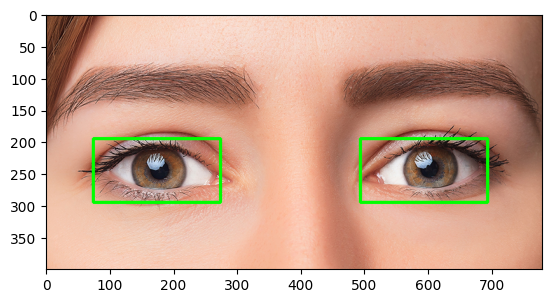

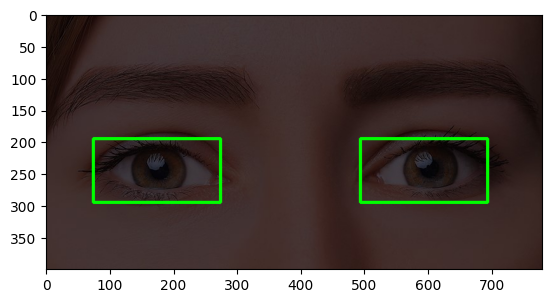

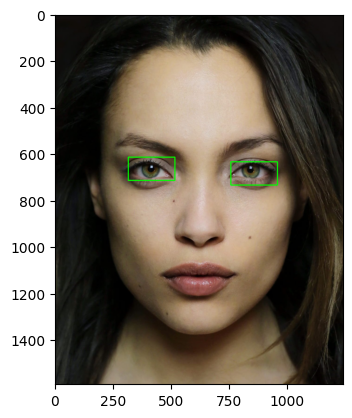

In [7]:
def zero_pad(image: np.ndarray, pad_height: int, pad_width: int) -> np.ndarray:
    H, W = image.shape

    out = np.zeros((H + 2 * pad_height, W + 2 * pad_width))

    out[pad_height : pad_height + H, pad_width : pad_width + W] = image

    return out


def cross_correlation(f: np.ndarray, g: np.ndarray) -> np.ndarray:
    g_64 = g.astype(np.float64)
    f_64 = f.astype(np.float64)

    Hf, Wf = f.shape
    Hg, Wg = g.shape

    out = np.zeros((Hf, Wf))
    img_pad = zero_pad(f_64, Hg // 2, Wg // 2)
    sum_square_g_64 = np.sum(g_64**2)

    for i in range(Hf):
        for j in range(Wf):
            sliced_img = img_pad[i : i + Hg, j : j + Wg]
            k = np.sqrt(sum_square_g_64 * np.sum(sliced_img**2))
            out[i, j] = np.sum(sliced_img * g_64) / k

    return out


def zero_mean_cross_correlation(f: np.ndarray, g: np.ndarray) -> np.ndarray:
    g_mean = np.mean(g)

    g_zero_mean = g - g_mean

    out = cross_correlation(f, g_zero_mean)

    return out


def find_argmax(image: np.ndarray) -> tuple[int, int]:
    H, W = image.shape

    half_1 = image[:, : W // 2]
    half_2 = image[:, W // 2 :]

    max_1 = np.argwhere(np.abs(half_1) == np.max(np.abs(half_1)))[0]
    max_2 = np.argwhere(np.abs(half_2) == np.max(np.abs(half_2)))[0]
    max_2[1] += W // 2

    return max_1, max_2


def correlation_map(f: np.ndarray, g: np.ndarray) -> np.ndarray:
    _, hog_f = hog(
        f,
        channel_axis=-1,
        cells_per_block=(1, 1),
        orientations=8,
        pixels_per_cell=(20, 20),
        visualize=True,
    )

    _, hog_g = hog(
        g,
        channel_axis=-1,
        cells_per_block=(1, 1),
        orientations=8,
        pixels_per_cell=(20, 20),
        visualize=True,
    )

    out = zero_mean_cross_correlation(hog_f, hog_g)

    return out


eye = cv2.imread("hog/eye.png")
eye = cv2.cvtColor(eye.copy(), cv2.COLOR_BGR2RGB)

all_eyes = glob.glob("hog/*.jpg")

for i in range(len(all_eyes)):
    new_eyes = cv2.imread(all_eyes[i])
    new_eyes = cv2.cvtColor(new_eyes.copy(), cv2.COLOR_BGR2RGB)

    res = correlation_map(new_eyes, eye)
    eye_1, eye_2 = find_argmax(res)

    out = new_eyes.copy()
    cv2.rectangle(out, eye_1[::-1] - [100, 50], eye_1[::-1] + [100, 50], (0, 255, 0), 3)
    cv2.rectangle(out, eye_2[::-1] - [100, 50], eye_2[::-1] + [100, 50], (0, 255, 0), 3)

    plt.figure()
    plt.imshow(out)